# LaLiga Transfer Market Analytics (2019–2022)

## Understanding how transfer spending influences club performance.

### Author
Eshaan Dangarikar

---

### Project Objective

This project analyzes whether football clubs in LaLiga that spend more in the transfer market actually achieve better sporting performance.

The analysis combines:

- Transfer market data (2019–2022)
- Match results
- Club performance statistics

to answer questions such as:

- Does spending more lead to more league points?
- Which clubs are the smartest spenders?
- Which clubs overspend without improving performance?
- Which transfer strategies are most effective?



# Football Transfer Market & Sporting Performance Analysis

## Analyzing the relationship between Transfer Strategy, Financial Investment and Club Performance

### Project Overview

This project analyzes football transfer activity and its relationship with sporting performance across selected Spanish football clubs in the LaLiga league over four seasons, from 2019/20 to 2022/23.

The objective is to understand whether financial investment in player recruitment translates into improved sporting performance and, more importantly, whether clubs can achieve strong results through efficient transfer strategies rather than simply just spending more money.

The analysis combines football transfer data with club performance data to examine:

- Transfer spending and recruitment activity.
- Types of player transfers.
- Club-level transfer strategies.
- League points and sporting performance.
- The relationship between transfer spending and league performance.
- Transfer spending efficiency.
- Smart spending versus high spending.
- Transfer strategies associated with stronger sporting outcomes.

The project ultimately aims to provide insights from a **Sporting Director and Football Operations perspective**, helping answer an important question:

> **Does success in Club football in the Spanish league LaLiga EA Sports come from spending more or from spending smarter?**

---

## Business Questions

This analysis aims to answer the following questions:

1. How active are football clubs in the transfer market?

2. What types of transfers are most commonly used by the clubs?

3. Is higher transfer spending associated with better league performance?

4. How strong is the relationship between transfer spending and league points?

5. Can clubs achieve strong sporting performance with relatively low transfer investment?

6. Which clubs demonstrate the characteristics of a "Smart Spender"?

7. Which clubs spend heavily but fail to achieve proportionate sporting success?

8. Which transfer strategies appear to be associated with stronger sporting performance?

9. From a Sporting Director's perspective, what transfer strategy provides the best balance between financial investment and sporting outcomes?

---   

##  Analytical Approach

The project follows a structured analytical process:

**Transfer data → Cleaning → Club-level aggregation → Performance data → Correlation → Spending comparison → Regression → Efficiency → Sporting Director Matrix → Recommendations → Conclusion**

The analysis uses descriptive statistics, correlation analysis, regression analysis, comparative spending analysis, and a transfer strategy efficiency framework to evaluate the relationship between recruitment investment and sporting performance.

# Data Collection

In [1]:
print("LaLiga")
import pandas as pd
df = pd.read_csv("primera-division (1).csv")

print("First 5 rows:")
display(df.head())

print("Dataset size (rows, columns):")
print(df.shape)

print("Column names:")
print(df.columns.tolist())

print("Available seasons:")
print(df["season"].unique())

print(df["season"].unique()[-10:])

# selecting the 5 seasons available in dataset for the project
project_seasons = [
    "2019/2020",
    "2020/2021",
    "2021/2022",
    "2022/2023",
    "2023/2024"
]

# filter the dataset to only these seasons
df_project = df[df["season"].isin(project_seasons)]

# number of rows and columns
print("Project dataset size:", df_project.shape)

# number of transfers in each season
print("\nTransfers by season:")
print(df_project["season"].value_counts().sort_index())

# selecting only players coming INTO LaLiga clubs
df_incoming = df_project[df_project["transfer_movement"] == "in"]

# number of incoming transfers
print("Incoming transfers:", df_incoming.shape)

# number of incoming transfers by season
print("\nIncoming transfers by season:")
print(df_incoming["season"].value_counts().sort_index())

# count unique players in incoming transfer dataset
unique_players = df_incoming["player_name"].nunique()

print("Number of unique players:", unique_players)

# count how many times each player appears
player_transfer_counts = df_incoming["player_name"].value_counts()

# players who appear more than once
print(player_transfer_counts[player_transfer_counts > 1].head(20))

# most common transfer fee descriptions
print(df_incoming["fee"].value_counts().head(30))

# records where the fee is "-"
dash_fee_records = df_incoming[df_incoming["fee"] == "-"]

# display the first 30 records
display(dash_fee_records.head(30))

# transfer movement and other relevant information
print(dash_fee_records[
    ["club_name", "player_name", "age", "position",
     "club_involved_name", "fee", "transfer_movement",
     "transfer_period", "fee_cleaned", "season"]
].head(30))

# keeping only seasons from 2019/2020 onwards
df_project = df[df["season"].str[:4].astype(int) >= 2019].copy()

print("Project dataset size:", df_project.shape)

print("\nSeasons included:")
print(df_project["season"].value_counts().sort_index())

# selecting only incoming transfers
df_incoming = df_project[
    df_project["transfer_movement"].str.lower().str.strip() == "in"
].copy()

print("Incoming transfers:", df_incoming.shape)

print("\nIncoming transfers by season:")
print(df_incoming["season"].value_counts().sort_index())

# incoming transfers where the fee is "-"
dash_fee_records = df_incoming[df_incoming["fee"] == "-"].copy()

# all unique previous clubs involved
print("Number of unique clubs involved:")
print(dash_fee_records["club_involved_name"].nunique())

print("\nPrevious clubs involved in '-' transfers:")
print(dash_fee_records["club_involved_name"].value_counts())

# free transfers
free_transfers = df_incoming[
    df_incoming["fee"].str.lower().str.contains("free transfer", na=False)
].copy()

print("\n")
print("Number of free transfers:", len(free_transfers))

print("\nExamples of free transfers:")
display(
    free_transfers[
        [
            "club_name",
            "player_name",
            "age",
            "position",
            "club_involved_name",
            "fee",
            "season"
        ]
    ].head(20)
)

# loan transfers
loan_transfers = df_incoming[
    df_incoming["fee"].str.lower().str.contains("loan", na=False)
].copy()

print("Number of loan-related incoming transfers:", len(loan_transfers))

print("\nLoan-related transfer descriptions:")
print(loan_transfers["fee"].value_counts().head(20))

# players returning from loans
loan_returns = df_incoming[
    df_incoming["fee"].str.lower().str.contains("end of loan", na=False)
].copy()

print("\n")
print("Number of loan returns:", len(loan_returns))

print("\nLoan return records by season:")
print(loan_returns["season"].value_counts().sort_index())

import numpy as np

df_transfers = df_incoming.copy()

def classify_transfer(row):
    fee = str(row["fee"]).lower().strip()
    source = str(row["club_involved_name"]).lower().strip()

    if "end of loan" in fee:
        return "Loan Return"

    if "loan" in fee:
        return "Loan"

    if fee == "free transfer":
        return "Free Transfer"

    if fee == "-":
        if any(x in source for x in [" b", "u19", "u19", "prom", "athletic", "atl. madrid b", "castilla"]):
            return "Internal Promotion"
        elif source == "without club":
            return "Free Transfer"
        else:
            return "Unknown"

    if fee == "?":
        return "Unknown"

    return "Permanent Transfer"

df_transfers["transfer_type"] = df_transfers.apply(classify_transfer, axis=1)

print(df_transfers["transfer_type"].value_counts())

summary = df_transfers.groupby(
    ["season", "transfer_type"]
).size().unstack(fill_value=0)

print(summary)

club_summary = df_transfers.groupby("club_name").agg(
    total_transfers=("player_name", "count"),
    avg_age=("age", "mean"),
    unique_players=("player_name", "nunique")
).sort_values("total_transfers", ascending=False)

print("\n")
print(club_summary.head(15))

paid = df_transfers[
    (df_transfers["transfer_type"] == "Permanent Transfer") &
    (df_transfers["fee_cleaned"].notna())
].copy()

club_spending = paid.groupby("club_name").agg(
    total_spending=("fee_cleaned", "sum"),
    average_fee=("fee_cleaned", "mean"),
    number_of_paid_transfers=("player_name", "count")
).sort_values("total_spending", ascending=False)

print("\n")
print(club_spending)

strategy = pd.crosstab(
    df_transfers["club_name"],
    df_transfers["transfer_type"]
)

print(strategy)
strategy_pct = strategy.div(strategy.sum(axis=1), axis=0) * 100

print(strategy_pct.round(1))

age_analysis = df_transfers.groupby("transfer_type")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

print(age_analysis)
age_groups = pd.cut(
    df_transfers["age"],
    bins=[0, 21, 24, 28, 35, 100],
    labels=["U21", "21-24", "25-28", "29-35", "36+"]
)

print(pd.crosstab(
    df_transfers["transfer_type"],
    age_groups
))

position_analysis = pd.crosstab(
    df_transfers["position"],
    df_transfers["transfer_type"]
)

print(position_analysis)
print(
    df_transfers["position"].value_counts().head(15)
)

fee_by_club = paid.groupby("club_name")["fee_cleaned"].agg(
    ["count", "sum", "mean", "median"]
).sort_values("sum", ascending=False)

print(fee_by_club.round(2))

# genuine acquisition events
acquisitions = df_transfers[
    df_transfers["transfer_type"].isin(
        ["Permanent Transfer", "Free Transfer", "Loan"]
    )
].copy()

# summer transfers only
summer_acquisitions = acquisitions[
    acquisitions["transfer_period"].str.lower() == "summer"
].copy()

print("Summer acquisitions:", len(summer_acquisitions))
print("Unique players:", summer_acquisitions["player_name"].nunique())

display(
    summer_acquisitions[
        [
            "club_name",
            "player_name",
            "age",
            "position",
            "club_involved_name",
            "fee",
            "transfer_type",
            "season"
        ]
    ].head(30)
)



LaLiga
First 5 rows:


,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
0,Real Sociedad,Alberto López,23.0,Goalkeeper,Real Sociedad B,-,in,Summer,NaN,Primera Division,1992,1992/1993,Spain
1,Real Sociedad,Iñigo Idiakez,18.0,Attacking Midfield,R. Sociedad U19,-,in,Summer,NaN,Primera Division,1992,1992/1993,Spain
2,Real Sociedad,José González,27.0,Goalkeeper,Valencia,?,out,Summer,NaN,Primera Division,1992,1992/1993,Spain
3,Cádiz CF,Igor Stimac,24.0,Centre-Back,Hajduk Split,?,in,Summer,NaN,Primera Division,1992,1992/1993,Spain
4,Cádiz CF,Quino,21.0,attack,CD Málaga,?,in,Summer,NaN,Primera Division,1992,1992/1993,Spain


Dataset size (rows, columns):
(17380, 13)
Column names:
['club_name', 'player_name', 'age', 'position', 'club_involved_name', 'fee', 'transfer_movement', 'transfer_period', 'fee_cleaned', 'league_name', 'year', 'season', 'country']
Available seasons:
['1992/1993' '1993/1994' '1994/1995' '1995/1996' '1996/1997' '1997/1998'
 '1998/1999' '1999/2000' '2000/2001' '2001/2002' '2002/2003' '2003/2004'
 '2004/2005' '2005/2006' '2006/2007' '2007/2008' '2008/2009' '2009/2010'
 '2010/2011' '2011/2012' '2012/2013' '2013/2014' '2014/2015' '2015/2016'
 '2016/2017' '2017/2018' '2018/2019' '2019/2020' '2020/2021' '2021/2022'
 '2022/2023']
['2013/2014' '2014/2015' '2015/2016' '2016/2017' '2017/2018' '2018/2019'
 '2019/2020' '2020/2021' '2021/2022' '2022/2023']
Project dataset size: (2905, 13)

Transfers by season:
season
2019/2020    848
2020/2021    692
2021/2022    632
2022/2023    733
Name: count, dtype: int64
Incoming transfers: (1464, 13)

Incoming transfers by season:
season
2019/2020    431
2020/

,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
14481,FC Barcelona,Juan Miranda,19.0,Left-Back,Barcelona B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14482,FC Barcelona,Carles Pérez,21.0,Right Winger,Barcelona B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14483,FC Barcelona,Moussa Wagué,20.0,Right-Back,Barcelona B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14521,Atlético de Madrid,Víctor Mollejo,18.0,Right Winger,Atl. Madrid B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14522,Atlético de Madrid,Francisco Montero,20.0,Centre-Back,Atl. Madrid B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14557,Real Madrid,Javi Sánchez,22.0,Centre-Back,RM Castilla,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14558,Real Madrid,Dani Gómez,20.0,Centre-Forward,RM Castilla,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14559,Real Madrid,Jorge de Frutos,22.0,Right Winger,RM Castilla,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14628,Valencia CF,Álex Centelles,19.0,Left-Back,Valencia B,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain
14672,Sevilla FC,Javi Díaz,22.0,Goalkeeper,Sevilla Atl.,-,in,Summer,NaN,Primera Division,2019,2019/2020,Spain


                    club_name        player_name   age            position  \
14481            FC Barcelona       Juan Miranda  19.0           Left-Back   
14482            FC Barcelona       Carles Pérez  21.0        Right Winger   
14483            FC Barcelona       Moussa Wagué  20.0          Right-Back   
14521      Atlético de Madrid     Víctor Mollejo  18.0        Right Winger   
14522      Atlético de Madrid  Francisco Montero  20.0         Centre-Back   
14557             Real Madrid       Javi Sánchez  22.0         Centre-Back   
14558             Real Madrid         Dani Gómez  20.0      Centre-Forward   
14559             Real Madrid    Jorge de Frutos  22.0        Right Winger   
14628             Valencia CF     Álex Centelles  19.0           Left-Back   
14672              Sevilla FC          Javi Díaz  22.0          Goalkeeper   
14705         Athletic Bilbao       Hodei Oleaga  22.0          Goalkeeper   
14706         Athletic Bilbao      Iñigo Vicente  21.0         L

,club_name,player_name,age,position,club_involved_name,fee,season
14520,Atlético de Madrid,Héctor Herrera,29.0,Central Midfield,FC Porto,free transfer,2019/2020
14556,Real Madrid,Takefusa Kubo,18.0,Right Winger,FC Tokyo,free transfer,2019/2020
14590,Getafe CF,David Timor,29.0,Defensive Midfield,UD Las Palmas,free transfer,2019/2020
14591,Getafe CF,Raúl Carnero,30.0,Left-Back,Girona,free transfer,2019/2020
14592,Getafe CF,Xabi Etxeita,31.0,Centre-Back,Athletic,free transfer,2019/2020
14623,Valencia CF,Jason,24.0,Right Winger,Levante,free transfer,2019/2020
14624,Valencia CF,Eliaquim Mangala,28.0,Centre-Back,Man City,free transfer,2019/2020
14625,Valencia CF,Àlex Carbonell,21.0,Central Midfield,Córdoba CF,free transfer,2019/2020
14626,Valencia CF,Salva Ruiz,24.0,Left-Back,RCD Mallorca,free transfer,2019/2020
14669,Sevilla FC,Nemanja Gudelj,27.0,Defensive Midfield,GZ Evergrande,free transfer,2019/2020


Number of loan-related incoming transfers: 811

Loan-related transfer descriptions:
fee
loan transfer              215
End of loanJun 30, 2019    126
End of loanJun 30, 2022    116
End of loanJun 30, 2021     97
End of loanJul 21, 2020     45
End of loanJun 30, 2020     36
End of loanJul 20, 2020     25
Loan fee:€500Th.            13
End of loanAug 17, 2020      8
End of loanAug 24, 2020      8
End of loanJul 31, 2020      6
End of loanDec 31, 2019      5
End of loanAug 31, 2020      5
End of loanDec 31, 2022      4
End of loanJan 30, 2023      4
End of loanJul 27, 2020      4
Loan fee:€2.00m              4
Loan fee:€1.50m              3
End of loanAug 12, 2020      3
Loan fee:€200Th.             3
Name: count, dtype: int64


Number of loan returns: 556

Loan return records by season:
season
2019/2020    159
2020/2021    158
2021/2022    106
2022/2023    133
Name: count, dtype: int64
transfer_type
Loan Return           556
Permanent Transfer    292
Loan                  255
Free Transf

,club_name,player_name,age,position,club_involved_name,fee,transfer_type,season
14475,FC Barcelona,Antoine Griezmann,28.0,Second Striker,Atlético Madrid,€120.00m,Permanent Transfer,2019/2020
14476,FC Barcelona,Frenkie de Jong,22.0,Central Midfield,Ajax,€86.00m,Permanent Transfer,2019/2020
14477,FC Barcelona,Neto,29.0,Goalkeeper,Valencia,€26.00m,Permanent Transfer,2019/2020
14478,FC Barcelona,Junior Firpo,22.0,Left-Back,Real Betis,€20.00m,Permanent Transfer,2019/2020
14479,FC Barcelona,Pedri,16.0,Central Midfield,UD Las Palmas,€17.50m,Permanent Transfer,2019/2020
14480,FC Barcelona,Marc Cucurella,20.0,Left-Back,SD Eibar,€4.00m,Permanent Transfer,2019/2020
14512,Atlético de Madrid,João Félix,19.0,Second Striker,Benfica,€127.20m,Permanent Transfer,2019/2020
14513,Atlético de Madrid,Marcos Llorente,24.0,Central Midfield,Real Madrid,€30.00m,Permanent Transfer,2019/2020
14514,Atlético de Madrid,Mario Hermoso,24.0,Centre-Back,Espanyol,€25.00m,Permanent Transfer,2019/2020
14515,Atlético de Madrid,Kieran Trippier,28.0,Right-Back,Spurs,€22.00m,Permanent Transfer,2019/2020


# Data Cleaning & Preprocessing

In [2]:
import pandas as pd
import numpy as np

# loading the two csv files

transfer_file = "primera-division (1).csv"
match_file = "spanish_football_games.csv"

transfers = pd.read_csv(transfer_file, encoding="latin1")
matches = pd.read_csv(match_file, encoding="utf-16") # Changed encoding to utf-16

print("Transfer dataset loaded:", transfers.shape)
print("Match dataset loaded:", matches.shape)



# preparing the transfer data

# keep only incoming transfers
transfers_in = transfers[
    transfers["transfer_movement"].astype(str).str.lower() == "in"
].copy()

# keep only summer transfers
summer_transfers = transfers_in[
    transfers_in["transfer_period"].astype(str).str.lower() == "summer"
].copy()

# convert season:
# 2019/2020 -> 2019
# 2020/2021 -> 2020
# etc.
summer_transfers["season"] = (
    summer_transfers["season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

# making sure fee_cleaned is numeric
summer_transfers["fee_cleaned"] = pd.to_numeric(
    summer_transfers["fee_cleaned"],
    errors="coerce"
)

# define and applying classify_transfer to create 'transfer_type'
def classify_transfer(row):
    fee = str(row["fee"]).lower().strip()
    source = str(row["club_involved_name"]).lower().strip()

    if "end of loan" in fee:
        return "Loan Return"

    if "loan" in fee:
        return "Loan"

    if fee == "free transfer":
        return "Free Transfer"

    if fee == "-":
        if any(x in source for x in [" b", "u19", "u19", "prom", "athletic", "atl. madrid b", "castilla"]):
            return "Internal Promotion"
        elif source == "without club":
            return "Free Transfer"
        else:
            return "Unknown"

    if fee == "?":
        return "Unknown"

    return "Permanent Transfer"

summer_transfers["transfer_type"] = summer_transfers.apply(classify_transfer, axis=1)


# creating transfer summary
# one row = one club + one season


transfer_summary = (
    summer_transfers
    .groupby(["club_name", "season"])
    .agg(
        total_transfers=("player_name", "count"),
        unique_players=("player_name", "nunique"),
        avg_age=("age", "mean"),
        total_spending=("fee_cleaned", "sum"),
        number_of_paid_transfers=("fee_cleaned", lambda x: x.notna().sum())
    )
    .reset_index()
)

# rounding the average age
transfer_summary["avg_age"] = transfer_summary["avg_age"].round(2)



# creating transfer type counts

transfer_type_counts = pd.crosstab(
    [
        summer_transfers["club_name"],
        summer_transfers["season"]
    ],
    summer_transfers["transfer_type"]
).reset_index()

# merging transfer type counts into transfer summary
transfer_summary = transfer_summary.merge(
    transfer_type_counts,
    on=["club_name", "season"],
    how="left"
)



# match data

#keeping only seasons 2019, 2020, 2021, 2022
matches = matches[
    matches["Season"].isin([2019, 2020, 2021, 2022])
].copy()


# creating home team performance

home = matches[
    [
        "Season",
        "Home Team",
        "Home Goals",
        "Away Goals",
        "Home Points"
    ]
].copy()

home.columns = [
    "season",
    "club_name",
    "goals_scored",
    "goals_conceded",
    "points"
]

# calculating the wins, draws and losses for home matches
home["wins"] = (home["points"] == 3).astype(int)
home["draws"] = (home["points"] == 1).astype(int)
home["losses"] = (home["points"] == 0).astype(int)



# away team performaces

away = matches[
    [
        "Season",
        "Away Team",
        "Away Goals",
        "Home Goals",
        "Away Points"
    ]
].copy()

away.columns = [
    "season",
    "club_name",
    "goals_scored",
    "goals_conceded",
    "points"
]

# calculating the wins, draws and losses for away matches
away["wins"] = (away["points"] == 3).astype(int)
away["draws"] = (away["points"] == 1).astype(int)
away["losses"] = (away["points"] == 0).astype(int) # this was home['losses'] earlier, changed to away['losses']


# combining the home and away performances

all_matches = pd.concat(
    [home, away],
    ignore_index=True
)



# club performance summary

performance_summary = (
    all_matches
    .groupby(["club_name", "season"])
    .agg(
        points=("points", "sum"),
        goals_scored=("goals_scored", "sum"),
        goals_conceded=("goals_conceded", "sum"),
        wins=("wins", "sum"),
        draws=("draws", "sum"),
        losses=("losses", "sum")
    )
    .reset_index()
)

# goal difference
performance_summary["goal_difference"] = (
    performance_summary["goals_scored"]
    - performance_summary["goals_conceded"]
)



# standardizing the club names
# match dataset names -> transfer dataset names

club_name_mapping = {

    "Alavés": "Deportivo Alavés",
    "Athletic": "Athletic Bilbao",
    "Atlético": "Atlético de Madrid",
    "Barcelona": "FC Barcelona",
    "Celta": "Celta de Vigo",
    "Eibar": "SD Eibar",
    "Espanyol": "RCD Espanyol Barcelona",
    "Getafe": "Getafe CF",
    "Girona": "Girona FC",
    "Huesca": "SD Huesca",
    "Leganés": "CD Leganés",
    "Levante": "Levante UD",
    "R. Sociedad": "Real Sociedad",
    "Rayo Vallecano": "Rayo Vallecano",
    "Real Betis": "Real Betis Balompié",
    "Real Madrid": "Real Madrid",
    "Real Valladolid": "Real Valladolid CF",
    "Sevilla": "Sevilla FC",
    "Valencia": "Valencia CF",
    "Villarreal": "Villarreal CF",
    "Granada": "Granada CF",
    "Mallorca": "RCD Mallorca",
    "Osasuna": "CA Osasuna",
    "Cádiz": "Cádiz CF",
    "Elche": "Elche CF"
}

performance_summary["club_name"] = (
    performance_summary["club_name"]
    .replace(club_name_mapping)
)



# merging transfer and performance data

final_data = transfer_summary.merge(
    performance_summary,
    on=["club_name", "season"],
    how="inner"
)


# sorting final dataset

final_data = final_data.sort_values(
    ["season", "club_name"]
).reset_index(drop=True)


# result display

print("\n")
print("FINAL DATASET")

print("Dataset size:", final_data.shape)

print("\nColumns:")
print(final_data.columns.tolist())

print("\nFirst 10 rows:")
display(final_data.head(10))


# checking seasons

print("\nSeasons included:")
print(sorted(final_data["season"].unique()))


# checking clubs

print("\nNumber of unique clubs:")
print(final_data["club_name"].nunique())


# checking the missing values

print("\nMissing values:")
display(final_data.isnull().sum())


# final dataset

final_data.to_csv(
    "final_football_transfer_performance_dataset.csv",
    index=False
)

print(
    "clean dataset has been saved as: "
    "final_football_transfer_performance_dataset.csv"
)


Transfer dataset loaded: (17380, 13)
Match dataset loaded: (26558, 11)


FINAL DATASET
Dataset size: (54, 20)

Columns:
['club_name', 'season', 'total_transfers', 'unique_players', 'avg_age', 'total_spending', 'number_of_paid_transfers', 'Free Transfer', 'Internal Promotion', 'Loan', 'Loan Return', 'Permanent Transfer', 'Unknown', 'points', 'goals_scored', 'goals_conceded', 'wins', 'draws', 'losses', 'goal_difference']

First 10 rows:


,club_name,season,total_transfers,unique_players,avg_age,total_spending,number_of_paid_transfers,Free Transfer,Internal Promotion,Loan,Loan Return,Permanent Transfer,Unknown,points,goals_scored,goals_conceded,wins,draws,losses,goal_difference
0,Athletic Bilbao,2019,10,10,23.90,0.00,0,0,5,0,5,0,0,53,41,45,13,14,11,-4
1,Celta de Vigo,2019,14,14,25.29,22.90,6,2,1,3,6,2,0,41,53,62,10,11,17,-9
2,FC Barcelona,2019,19,17,22.63,273.50,6,0,3,0,10,6,0,87,90,36,26,9,3,54
3,Getafe CF,2019,17,17,26.06,12.00,7,3,0,3,7,4,0,59,48,35,15,14,9,13
4,Levante UD,2019,18,18,25.78,14.60,10,6,0,1,6,3,2,44,59,66,11,11,16,-7
5,RCD Espanyol Barcelona,2019,14,14,24.07,18.50,4,2,4,3,3,2,0,53,48,50,14,11,13,-2
6,Real Madrid,2019,19,19,22.37,325.50,8,1,3,1,8,6,0,68,63,46,21,5,12,17
7,Real Sociedad,2019,12,12,22.67,31.75,6,1,4,1,2,4,0,50,45,46,13,11,14,-1
8,Real Valladolid CF,2019,15,15,22.60,1.00,1,0,2,6,6,1,0,41,32,51,10,11,17,-19
9,SD Eibar,2019,16,16,25.62,17.30,11,5,0,0,5,6,0,47,46,50,11,14,13,-4



Seasons included:
[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Number of unique clubs:
18

Missing values:


,0
club_name,0
season,0
total_transfers,0
unique_players,0
avg_age,0
total_spending,0
number_of_paid_transfers,0
Free Transfer,0
Internal Promotion,0
Loan,0


clean dataset has been saved as: final_football_transfer_performance_dataset.csv


In [3]:
import pandas as pd
import numpy as np

# start of df_transfers definition (from 9c5k19jJqjod)
# load the base dataframe
df = pd.read_csv("primera-division (1).csv")

# keep only seasons from 2019/2020 onwards for df_project
df_project = df[df["season"].str[:4].astype(int) >= 2019].copy()

# select only incoming transfers for df_incoming
df_incoming = df_project[
    df_project["transfer_movement"].str.lower().str.strip() == "in"
].copy()

# create df_transfers from df_incoming
df_transfers = df_incoming.copy()

def classify_transfer(row):
    fee = str(row["fee"]).lower().strip()
    source = str(row["club_involved_name"]).lower().strip()

    if "end of loan" in fee:
        return "Loan Return"

    if "loan" in fee:
        return "Loan"

    if fee == "free transfer":
        return "Free Transfer"

    if fee == "-":
        if any(x in source for x in [" b", "u19", "u19", "prom", "athletic", "atl. madrid b", "castilla"]):
            return "Internal Promotion"
        elif source == "without club":
            return "Free Transfer"
        else:
            return "Unknown"

    if fee == "?":
        return "Unknown"

    return "Permanent Transfer"

df_transfers["transfer_type"] = df_transfers.apply(classify_transfer, axis=1)
# end of df_transfers definition

# start of club_performance definition (from X9YRjKsgF3H5)
# reload match dataset with UTF-16 encoding
matches = pd.read_csv('spanish_football_games.csv', encoding='utf-16')

# keep only the seasons covered by our transfer dataset
project_seasons = [2019, 2020, 2021, 2022]
matches_project = matches[matches['Season'].isin(project_seasons)].copy()

home_stats = matches_project.groupby(['Season', 'Home Team']).agg(
    points=('Home Points', 'sum'),
    goals_scored=('Home Goals', 'sum'),
    goals_conceded=('Away Goals', 'sum'),
    wins=('Home Points', lambda x: (x == 3).sum()), # corrected to 3 points for a win
    draws=('Home Points', lambda x: (x == 1).sum()),
    losses=('Home Points', lambda x: (x == 0).sum())
).reset_index()
home_stats.rename(columns={'Home Team': 'club_name'}, inplace=True)


away_stats = matches_project.groupby(['Season', 'Away Team']).agg(
    points=('Away Points', 'sum'),
    goals_scored=('Away Goals', 'sum'),
    goals_conceded=('Home Goals', 'sum'),
    wins=('Away Points', lambda x: (x == 3).sum()), # corrected to 3 points for a win
    draws=('Away Points', lambda x: (x == 1).sum()),
    losses=('Away Points', lambda x: (x == 0).sum())
).reset_index()
away_stats.rename(columns={'Away Team': 'club_name'}, inplace=True)


# combining home and away performance
club_performance = pd.concat([home_stats, away_stats])

club_performance = club_performance.groupby(
    ['Season', 'club_name']
).sum().reset_index()

# goal difference
club_performance['goal_difference'] = (
    club_performance['goals_scored'] -
    club_performance['goals_conceded']
)

# club name mapping (from -gtaRZ9fIZTH and 5_5kNEi3Ih8W)
club_name_mapping = {
    'Alavés': 'Deportivo Alavés',
    'Athletic': 'Athletic Bilbao',
    'Atlético': 'Atlético de Madrid',
    'Barcelona': 'FC Barcelona',
    'Celta': 'Celta de Vigo',
    'Cádiz': 'Cádiz CF',
    'Eibar': 'SD Eibar',
    'Elche': 'Elche CF',
    'Espanyol': 'RCD Espanyol Barcelona',
    'Getafe': 'Getafe CF',
    'Girona': 'Girona FC',
    'Granada': 'Granada CF',
    'Huesca': 'SD Huesca',
    'Leganés': 'CD Leganés',
    'Levante': 'Levante UD',
    'Mallorca': 'RCD Mallorca',
    'Osasuna': 'CA Osasuna',
    'R. Sociedad': 'Real Sociedad',
    'Rayo Vallecano': 'Rayo Vallecano',
    'Real Betis': 'Real Betis Balompié',
    'Real Madrid': 'Real Madrid',
    'Real Sociedad': 'Real Sociedad',
    'Real Valladolid': 'Real Valladolid CF',
    'Sevilla': 'Sevilla FC',
    'Valencia': 'Valencia CF',
    'Villarreal': 'Villarreal CF'
}
club_performance['club_name'] = club_performance['club_name'].replace(club_name_mapping)
# end of club name mapping

# preprocessing from 4jZxDTl-KTlg and previous 7dZnshimpI1L attempt
club_performance = club_performance.rename(columns={'Season': 'season'})
# convert df_transfers['season'] to integer to match club_performance['season']
df_transfers['season'] = df_transfers['season'].str[:4].astype(int)

merged_data = pd.merge(
    df_transfers,
    club_performance,
    on=['club_name', 'season'],
    how='left'
)
# end of preprocessing

club_season = merged_data.groupby(['club_name', 'season']).agg(
    total_transfers=('player_name', 'count'),
    avg_age=('age', 'mean'),
    total_spending=('fee_cleaned', 'sum'),
    number_of_paid_transfers=('fee_cleaned', lambda x: x.notna().sum()),
    points=('points', 'first'),
    wins=('wins', 'first'),
    draws=('draws', 'first'),
    losses=('losses', 'first'),
    goals_scored=('goals_scored', 'first'),
    goals_conceded=('goals_conceded', 'first'),
    goal_difference=('goal_difference', 'first')
).reset_index()

#  Correlation Analysis

In [4]:

# basic transfer vs performance analysis

# main variables for study
analysis_data = final_data[
    [
        "club_name",
        "season",
        "total_transfers",
        "avg_age",
        "total_spending",
        "number_of_paid_transfers",
        "Free Transfer",
        "Internal Promotion",
        "Loan",
        "Loan Return",
        "Permanent Transfer",
        "Unknown",
        "points",
        "wins",
        "draws",
        "losses",
        "goals_scored",
        "goals_conceded",
        "goal_difference"
    ]
].copy()

# displaying the complete analysis dataset
print("Analysis dataset shape:", analysis_data.shape)

display(analysis_data.head(10))


# correlation analysis

correlation = analysis_data[
    [
        "total_transfers",
        "avg_age",
        "total_spending",
        "number_of_paid_transfers",
        "points",
        "wins",
        "draws",
        "losses",
        "goals_scored",
        "goals_conceded",
        "goal_difference"
    ]
].corr()

print("Correlation Matrix:")

display(correlation.round(2))

Analysis dataset shape: (54, 19)


,club_name,season,total_transfers,avg_age,total_spending,number_of_paid_transfers,Free Transfer,Internal Promotion,Loan,Loan Return,Permanent Transfer,Unknown,points,wins,draws,losses,goals_scored,goals_conceded,goal_difference
0,Athletic Bilbao,2019,10,23.90,0.00,0,0,5,0,5,0,0,53,13,14,11,41,45,-4
1,Celta de Vigo,2019,14,25.29,22.90,6,2,1,3,6,2,0,41,10,11,17,53,62,-9
2,FC Barcelona,2019,19,22.63,273.50,6,0,3,0,10,6,0,87,26,9,3,90,36,54
3,Getafe CF,2019,17,26.06,12.00,7,3,0,3,7,4,0,59,15,14,9,48,35,13
4,Levante UD,2019,18,25.78,14.60,10,6,0,1,6,3,2,44,11,11,16,59,66,-7
5,RCD Espanyol Barcelona,2019,14,24.07,18.50,4,2,4,3,3,2,0,53,14,11,13,48,50,-2
6,Real Madrid,2019,19,22.37,325.50,8,1,3,1,8,6,0,68,21,5,12,63,46,17
7,Real Sociedad,2019,12,22.67,31.75,6,1,4,1,2,4,0,50,13,11,14,45,46,-1
8,Real Valladolid CF,2019,15,22.60,1.00,1,0,2,6,6,1,0,41,10,11,17,32,51,-19
9,SD Eibar,2019,16,25.62,17.30,11,5,0,0,5,6,0,47,11,14,13,46,50,-4


Correlation Matrix:


,total_transfers,avg_age,total_spending,number_of_paid_transfers,points,wins,draws,losses,goals_scored,goals_conceded,goal_difference
total_transfers,1.00,0.09,0.42,0.73,0.08,0.08,-0.06,-0.06,0.05,-0.08,0.07
avg_age,0.09,1.00,-0.29,0.42,-0.45,-0.46,0.25,0.38,-0.37,0.37,-0.44
total_spending,0.42,-0.29,1.00,0.33,0.51,0.53,-0.35,-0.40,0.54,-0.24,0.50
number_of_paid_transfers,0.73,0.42,0.33,1.00,-0.14,-0.13,-0.00,0.16,-0.03,0.20,-0.12
points,0.08,-0.45,0.51,-0.14,1.00,0.99,-0.40,-0.92,0.84,-0.73,0.95
wins,0.08,-0.46,0.53,-0.13,0.99,1.00,-0.54,-0.84,0.85,-0.67,0.92
draws,-0.06,0.25,-0.35,-0.00,-0.40,-0.54,1.00,0.00,-0.45,-0.02,-0.31
losses,-0.06,0.38,-0.40,0.16,-0.92,-0.84,0.00,1.00,-0.73,0.81,-0.90
goals_scored,0.05,-0.37,0.54,-0.03,0.84,0.85,-0.45,-0.73,1.00,-0.40,0.90
goals_conceded,-0.08,0.37,-0.24,0.20,-0.73,-0.67,-0.02,0.81,-0.40,1.00,-0.76


From the above table, the values are positive as well as negative, ranging from -1 to +1. Its simple interpretation is:

+1 indicates a very strong positive relationship

+0.5 indicates a moderate positive relationship

0 means little or no linear relationship

-0.5 signifies a moderate negative relationship

-1 signifies a very strong negative relationship


To understand even better, please refer to this:

| Relationship                            | Correlation | Simple meaning                                                     |
| --------------------------------------- | ----------: | ------------------------------------------------------------------ |
| **Transfer spending & Points**          |    **0.51** | More spending is moderately associated with more points            |
| **Transfer spending & Wins**            |    **0.53** | More spending is moderately associated with more wins              |
| **Transfer spending & Goals scored**    |    **0.54** | More spending is moderately associated with scoring more goals     |
| **Transfer spending & Goal difference** |    **0.50** | More spending is moderately associated with better goal difference |
| **Average age & Points**                |   **-0.45** | Older squads tend to have fewer points in this dataset             |
| **Average age & Wins**                  |   **-0.46** | Older squads tend to have fewer wins                               |
| **Spending & Losses**                   |   **-0.40** | Higher spending is associated with fewer losses                    |
| **Points & Goal difference**            |    **0.95** | Strong relationship between points and goal difference             |

This does not mean that "Spending more helps clubs perform better", but rather something more nuanced.

 The matrix tells us that **transfer spending** has a moderate relationship with performance, but it is not strong enough to explain the performance by itself.

Because the spending & points correlation is only 0.51, not something like 0.90.
Regression confirms this as R² = 0.256, meaning ransfer spending alone explains approximately 25.6% of the variation in league points.

Roughly three quarters of the variation is related to other factors that aren't captured by this simple model.
This prevents one from making the simplistic conclusion that "the club with the biggest transfer budget will automatically perform best."

Smart Spender analysis reinforces this. For example, Real Sociedad in 2021 spent only €2.5m but earned 62 points, while several much higher spending club seasons performed considerably worse.


# Club Performance

In [5]:
# reload match dataset with UTF-16 encoding
matches = pd.read_csv('spanish_football_games.csv', encoding='utf-16')

print("Dataset size:", matches.shape)
print("\nColumn names:")
print(matches.columns.tolist())

print("\nFirst 5 rows:")
display(matches.head())

# keeping only the seasons covered by our transfer dataset
project_seasons = [2019, 2020, 2021, 2022]

matches_project = matches[matches['Season'].isin(project_seasons)].copy()

print("Filtered match dataset size:", matches_project.shape)

print("\nSeasons included:")
print(matches_project['Season'].value_counts().sort_index())

print("\nFirst 5 rows:")
display(matches_project.head())

# calculating total points, wins, draws, losses and goals for each club and season

home_stats = matches_project.groupby(['Season', 'Home Team']).agg(
    points=('Home Points', 'sum'),
    goals_scored=('Home Goals', 'sum'),
    goals_conceded=('Away Goals', 'sum'),
    wins=('Home Points', lambda x: (x == 2).sum()),
    draws=('Home Points', lambda x: (x == 1).sum()),
    losses=('Home Points', lambda x: (x == 0).sum())
).reset_index()

home_stats.rename(columns={'Home Team': 'club_name'}, inplace=True)


away_stats = matches_project.groupby(['Season', 'Away Team']).agg(
    points=('Away Points', 'sum'),
    goals_scored=('Away Goals', 'sum'),
    goals_conceded=('Home Goals', 'sum'),
    wins=('Away Points', lambda x: (x == 2).sum()),
    draws=('Away Points', lambda x: (x == 1).sum()),
    losses=('Away Points', lambda x: (x == 0).sum())
).reset_index()

away_stats.rename(columns={'Away Team': 'club_name'}, inplace=True)


# combining home and away performance
club_performance = pd.concat([home_stats, away_stats])

club_performance = club_performance.groupby(
    ['Season', 'club_name']
).sum().reset_index()

# calculating goal difference
club_performance['goal_difference'] = (
    club_performance['goals_scored'] -
    club_performance['goals_conceded']
)

print("Club performance dataset size:", club_performance.shape)

display(club_performance.head(20))

# correct club performance calculation using 3 points for a win

home_stats = matches_project.groupby(['Season', 'Home Team']).agg(
    points=('Home Points', 'sum'),
    goals_scored=('Home Goals', 'sum'),
    goals_conceded=('Away Goals', 'sum'),
    wins=('Home Points', lambda x: (x == 3).sum()),
    draws=('Home Points', lambda x: (x == 1).sum()),
    losses=('Home Points', lambda x: (x == 0).sum())
).reset_index()

home_stats.rename(columns={'Home Team': 'club_name'}, inplace=True)


away_stats = matches_project.groupby(['Season', 'Away Team']).agg(
    points=('Away Points', 'sum'),
    goals_scored=('Away Goals', 'sum'),
    goals_conceded=('Home Goals', 'sum'),
    wins=('Away Points', lambda x: (x == 3).sum()),
    draws=('Away Points', lambda x: (x == 1).sum()),
    losses=('Away Points', lambda x: (x == 0).sum())
).reset_index()

away_stats.rename(columns={'Away Team': 'club_name'}, inplace=True)


# combining the home and away performance
club_performance = pd.concat([home_stats, away_stats])

club_performance = club_performance.groupby(
    ['Season', 'club_name']
).sum().reset_index()

# calculating goal difference
club_performance['goal_difference'] = (
    club_performance['goals_scored'] -
    club_performance['goals_conceded']
)

print("\nClub performance dataset size:", club_performance.shape)

display(club_performance.head(20))

# checking number of clubs in each season
print(club_performance.groupby('Season')['club_name'].nunique())

# all seasons and number of records
print("\nRecords by season:")
print(club_performance['Season'].value_counts().sort_index())

# display the last 20 rows
print("\nLast 20 rows:")
display(club_performance.tail(20))

Dataset size: (26558, 11)

Column names:
['Season', 'Game', 'Score', 'Teams', 'Home Team', 'Away Team', 'Home Goals', 'Away Goals', 'Home Points', 'Away Points', 'Pools']

First 5 rows:


,Season,Game,Score,Teams,Home Team,Away Team,Home Goals,Away Goals,Home Points,Away Points,Pools
0,1929,1,2-3,Arenas de Getxo - Atlético,Arenas de Getxo,Atlético,2,3,0,2,2
1,1929,1,3-2,Espanyol - Real Unión de Irún,Espanyol,Real Unión de Irún,3,2,2,0,1
2,1929,1,1-1,R. Sociedad - Athletic,R. Sociedad,Athletic,1,1,1,1,X
3,1929,1,5-0,Real Madrid - CE Europa,Real Madrid,CE Europa,5,0,2,0,1
4,1929,1,0-2,Racing - Barcelona,Racing,Barcelona,0,2,0,2,2


Filtered match dataset size: (1520, 11)

Seasons included:
Season
2019    380
2020    380
2021    380
2022    380
Name: count, dtype: int64

First 5 rows:


,Season,Game,Score,Teams,Home Team,Away Team,Home Goals,Away Goals,Home Points,Away Points,Pools
24658,2019,1,0-0,Girona - Real Valladolid,Girona,Real Valladolid,0,0,1,1,X
24659,2019,1,0-3,Real Betis - Levante,Real Betis,Levante,0,3,0,3,2
24660,2019,1,1-1,Celta - Espanyol,Celta,Espanyol,1,1,1,1,X
24661,2019,1,1-2,Villarreal - R. Sociedad,Villarreal,R. Sociedad,1,2,0,3,2
24662,2019,1,3-0,Barcelona - Alavés,Barcelona,Alavés,3,0,3,0,1


Club performance dataset size: (80, 9)


,Season,club_name,points,goals_scored,goals_conceded,wins,draws,losses,goal_difference
0,2019,Alavés,50,39,50,0,11,14,-11
1,2019,Athletic,53,41,45,0,14,11,-4
2,2019,Atlético,76,55,29,0,10,6,26
3,2019,Barcelona,87,90,36,0,9,3,54
4,2019,Celta,41,53,62,0,11,17,-9
5,2019,Eibar,47,46,50,0,14,13,-4
6,2019,Espanyol,53,48,50,0,11,13,-2
7,2019,Getafe,59,48,35,0,14,9,13
8,2019,Girona,37,37,53,0,10,19,-16
9,2019,Huesca,33,43,65,0,12,19,-22



Club performance dataset size: (80, 9)


,Season,club_name,points,goals_scored,goals_conceded,wins,draws,losses,goal_difference
0,2019,Alavés,50,39,50,13,11,14,-11
1,2019,Athletic,53,41,45,13,14,11,-4
2,2019,Atlético,76,55,29,22,10,6,26
3,2019,Barcelona,87,90,36,26,9,3,54
4,2019,Celta,41,53,62,10,11,17,-9
5,2019,Eibar,47,46,50,11,14,13,-4
6,2019,Espanyol,53,48,50,14,11,13,-2
7,2019,Getafe,59,48,35,15,14,9,13
8,2019,Girona,37,37,53,9,10,19,-16
9,2019,Huesca,33,43,65,7,12,19,-22


Season
2019    20
2020    20
2021    20
2022    20
Name: club_name, dtype: int64

Records by season:
Season
2019    20
2020    20
2021    20
2022    20
Name: count, dtype: int64

Last 20 rows:


,Season,club_name,points,goals_scored,goals_conceded,wins,draws,losses,goal_difference
60,2022,Athletic,55,43,36,14,13,11,7
61,2022,Atlético,71,65,43,21,8,9,22
62,2022,Barcelona,73,68,38,21,10,7,30
63,2022,Celta,46,43,43,12,10,16,0
64,2022,Cádiz,39,35,51,8,15,15,-16
65,2022,Deportivo Alavés,31,31,65,8,7,23,-34
66,2022,Elche,42,40,52,11,9,18,-12
67,2022,Espanyol,42,40,53,10,12,16,-13
68,2022,Getafe,39,33,41,8,15,15,-8
69,2022,Granada,38,44,61,8,14,16,-17


# Data Merging

In [6]:
print(sorted(club_performance['club_name'].unique()))
club_performance['club_name'].unique()

['Alavés', 'Athletic', 'Atlético', 'Barcelona', 'Celta', 'Cádiz', 'Deportivo Alavés', 'Eibar', 'Elche', 'Espanyol', 'Getafe', 'Girona', 'Granada', 'Huesca', 'Leganés', 'Levante', 'Mallorca', 'Osasuna', 'R. Sociedad', 'Rayo Vallecano', 'Real Betis', 'Real Madrid', 'Real Sociedad', 'Real Valladolid', 'Sevilla', 'Valencia', 'Villarreal']


array(['Alavés', 'Athletic', 'Atlético', 'Barcelona', 'Celta', 'Eibar',
       'Espanyol', 'Getafe', 'Girona', 'Huesca', 'Leganés', 'Levante',
       'R. Sociedad', 'Rayo Vallecano', 'Real Betis', 'Real Madrid',
       'Real Valladolid', 'Sevilla', 'Valencia', 'Villarreal', 'Granada',
       'Mallorca', 'Osasuna', 'Cádiz', 'Elche', 'Deportivo Alavés',
       'Real Sociedad'], dtype=object)

In [7]:
if 'Season' in club_performance.columns and 'season' not in club_performance.columns:
    club_performance = club_performance.rename(columns={'Season': 'season'})

merged_data = pd.merge(
    df_transfers,
    club_performance,
    on=['club_name', 'season'],
    how='left'
)

print("\nMerged data head:")
print(merged_data.head())

merged_data.shape
merged_data.head()

merged_data['transfer_type'].value_counts()

transfer_counts = pd.crosstab(
    [merged_data['club_name'], merged_data['season']],
    merged_data['transfer_type']
).reset_index()

# identifying columns that exist in both club_season and transfer_counts (excluding merge keys)
transfer_type_columns = [col for col in transfer_counts.columns if col not in ['club_name', 'season']]

# drop these columns from club_season if they exist, to avoid merge conflicts
club_season = club_season.drop(columns=[col for col in transfer_type_columns if col in club_season.columns], errors='ignore')

club_season = pd.merge(
    club_season,
    transfer_counts,
    on=['club_name', 'season'],
    how='left'
)

club_season.shape
club_season.head(10)
club_season.columns
print("\n")
print("Transfer data seasons:")
print(df_incoming['season'].unique())
print("\n")
print("Performance data seasons:")
print(club_performance['season'].unique())
print("\n")
print("Merged data seasons:")
print(merged_data['season'].unique())

print("\n")
print("Transfer clubs:")
print(df_incoming['club_name'].unique())
print("\n")
print("Performance clubs:")
print(club_performance['club_name'].unique())

club_performance['club_name'] = club_performance['club_name'].replace({
    'Alavés': 'Deportivo Alavés',
    'Athletic': 'Athletic Bilbao',
    'Atlético': 'Atlético de Madrid',
    'Barcelona': 'FC Barcelona',
    'Celta': 'Celta de Vigo',
    'Eibar': 'SD Eibar',
    'Espanyol': 'RCD Espanyol Barcelona',
    'Getafe': 'Getafe CF',
    'Girona': 'Girona FC',
    'Huesca': 'SD Huesca',
    'Leganés': 'CD Leganés',
    'Levante': 'Levante UD',
    'R. Sociedad': 'Real Sociedad',
    'Rayo Vallecano': 'Rayo Vallecano',
    'Real Betis': 'Real Betis Balompié',
    'Real Madrid': 'Real Madrid',
    'Real Valladolid': 'Real Valladolid CF',
    'Sevilla': 'Sevilla FC',
    'Valencia': 'Valencia CF',
    'Villarreal': 'Villarreal CF',
    'Granada': 'Granada CF',
    'Mallorca': 'RCD Mallorca',
    'Osasuna': 'CA Osasuna',
    'Cádiz': 'Cádiz CF',
    'Elche': 'Elche CF'
})
club_performance['club_name'].unique()


Merged data head:
      club_name        player_name   age          position club_involved_name  \
0  FC Barcelona  Antoine Griezmann  28.0    Second Striker    Atlético Madrid   
1  FC Barcelona    Frenkie de Jong  22.0  Central Midfield               Ajax   
2  FC Barcelona               Neto  29.0        Goalkeeper           Valencia   
3  FC Barcelona       Junior Firpo  22.0         Left-Back         Real Betis   
4  FC Barcelona              Pedri  16.0  Central Midfield      UD Las Palmas   

        fee transfer_movement transfer_period  fee_cleaned       league_name  \
0  €120.00m                in          Summer        120.0  Primera Division   
1   €86.00m                in          Summer         86.0  Primera Division   
2   €26.00m                in          Summer         26.0  Primera Division   
3   €20.00m                in          Summer         20.0  Primera Division   
4   €17.50m                in          Summer         17.5  Primera Division   

   ...  seaso

array(['Deportivo Alavés', 'Athletic Bilbao', 'Atlético de Madrid',
       'FC Barcelona', 'Celta de Vigo', 'SD Eibar',
       'RCD Espanyol Barcelona', 'Getafe CF', 'Girona FC', 'SD Huesca',
       'CD Leganés', 'Levante UD', 'Real Sociedad', 'Rayo Vallecano',
       'Real Betis Balompié', 'Real Madrid', 'Real Valladolid CF',
       'Sevilla FC', 'Valencia CF', 'Villarreal CF', 'Granada CF',
       'RCD Mallorca', 'CA Osasuna', 'Cádiz CF', 'Elche CF'], dtype=object)

#  High spending vs Low spending clubs

Correlation between Transfer Spending and League Points:
0.506


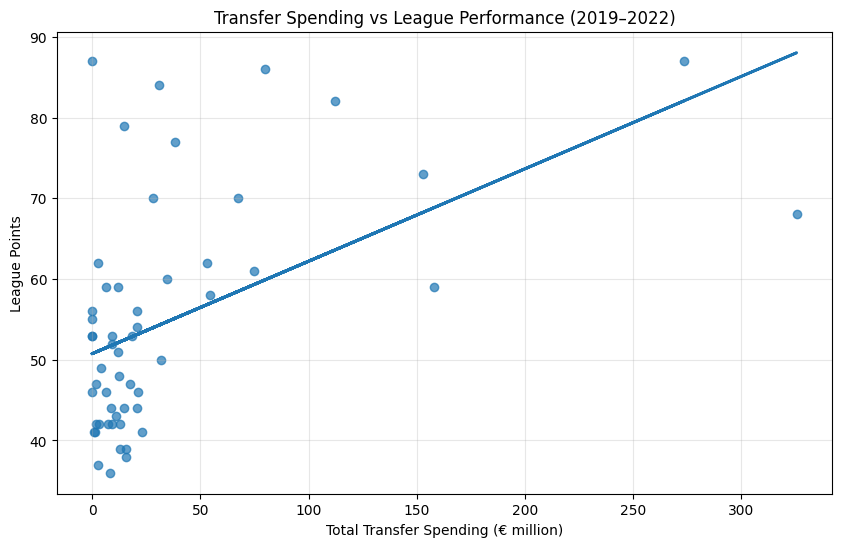


Interpretation:
There is a moderate positive relationship between transfer spending and league points.


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# transfer sepnding vs performance

# create copy of the analysis dataset
spending_analysis = analysis_data.copy()

# 1) correlation

correlation = spending_analysis['total_spending'].corr(
    spending_analysis['points']
)

print("Correlation between Transfer Spending and League Points:")
print(round(correlation, 3))


# 2) scatter plot


plt.figure(figsize=(10, 6))

plt.scatter(
    spending_analysis['total_spending'],
    spending_analysis['points'],
    alpha=0.7
)

# 3) adding trend line

x = spending_analysis['total_spending']
y = spending_analysis['points']

# linear trend line
slope, intercept = np.polyfit(x, y, 1)

trend_line = slope * x + intercept

plt.plot(
    x,
    trend_line,
    linewidth=2
)

# 4) adding labels

plt.xlabel('Total Transfer Spending (€ million)')
plt.ylabel('League Points')

plt.title(
    'Transfer Spending vs League Performance (2019–2022)'
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# 5) interpretation

print("\nInterpretation:")

if correlation >= 0.7:
    print("There is a strong positive relationship between transfer spending and league points.")
elif correlation >= 0.4:
    print("There is a moderate positive relationship between transfer spending and league points.")
elif correlation >= 0.2:
    print("There is a weak positive relationship between transfer spending and league points.")
elif correlation > -0.2:
    print("There is little or no linear relationship between transfer spending and league points.")
else:
    print("There is a negative relationship between transfer spending and league points.")

#  Linear Regression Analysis

In [9]:
import statsmodels.api as sm

# defining independent and dependent variables
X = analysis_data[['total_spending']]
y = analysis_data['points']

# adding constant
X = sm.add_constant(X)

# fitting the regression model
model = sm.OLS(y, X).fit()

# display of results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     17.89
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           9.50e-05
Time:                        09:56:27   Log-Likelihood:                -211.55
No. Observations:                  54   AIC:                             427.1
Df Residuals:                      52   BIC:                             431.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             50.7459      1.931     26.

Interpretation: The regression shows a statistically significant positive relationship between transfer spending and league points. However, transfer spending explains only 25.6% of the variation in league performance. This suggests that while financial investment contributes to sporting success, factors such as recruitment quality, player development, coaching and squad management also play an important role.



# Median transfer spending

In [10]:
# median transfer spending
median_spending = analysis_data['total_spending'].median()

# spending groups
analysis_data['spending_group'] = analysis_data['total_spending'].apply(
    lambda x: 'High Spending' if x >= median_spending else 'Low Spending'
)

# comparison of average performance
comparison = analysis_data.groupby('spending_group').agg(
    average_spending=('total_spending', 'mean'),
    average_points=('points', 'mean'),
    average_wins=('wins', 'mean'),
    average_goal_difference=('goal_difference', 'mean'),
    number_of_observations=('club_name', 'count')
)

print("\nMedian Transfer Spending:", median_spending)
print("\nHigh vs Low Spending Comparison:")
print(comparison)


Median Transfer Spending: 13.030000000000001

High vs Low Spending Comparison:
                average_spending  average_points  average_wins  \
spending_group                                                   
High Spending          64.092593       60.259259     16.629630   
Low Spending            5.324519       49.185185     12.555556   

                average_goal_difference  number_of_observations  
spending_group                                                   
High Spending                 12.888889                      27  
Low Spending                  -2.888889                      27  


# Visualizations



GRAPH 1: TOTAL TRANSFER SPENDING VS LEAGUE POINTS


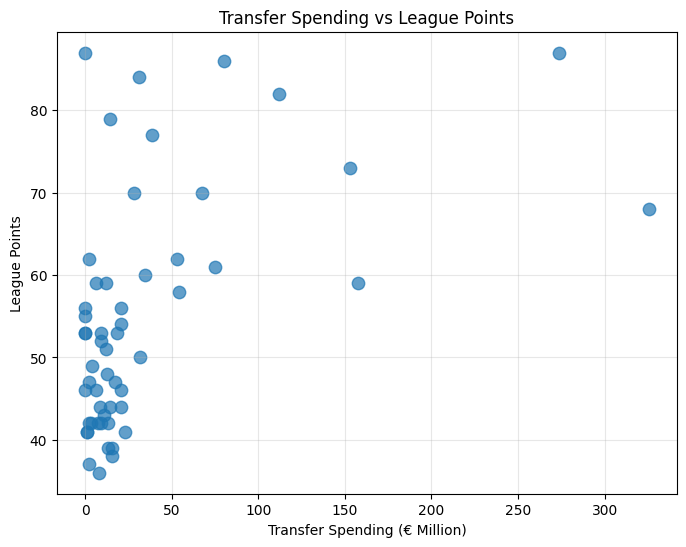


Interpretation:
The scatter plot shows a clear upward trend between transfer spending and league points. Clubs investing more in transfers generally achieved higher league points, although some clubs performed well despite lower spending, highlighting the importance of efficient recruitment.


GRAPH 2: CORRELATION HEATMAP


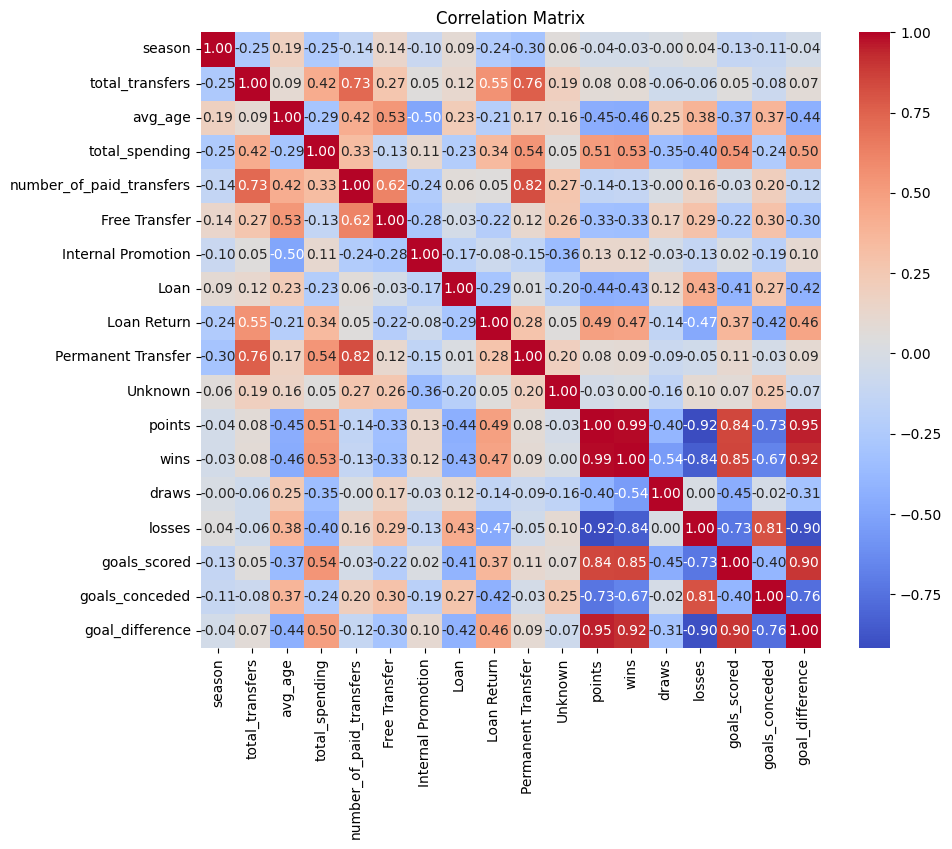


Interpretation:
The heatmap shows that total transfer spending has a moderate positive correlation (0.51) with league points, indicating that higher spending is generally associated with better league performance. However, spending alone is not sufficient, as factors like squad quality and tactical management also influence results.


GRAPH 3: TOP 10 BIGGEST SPENDERS


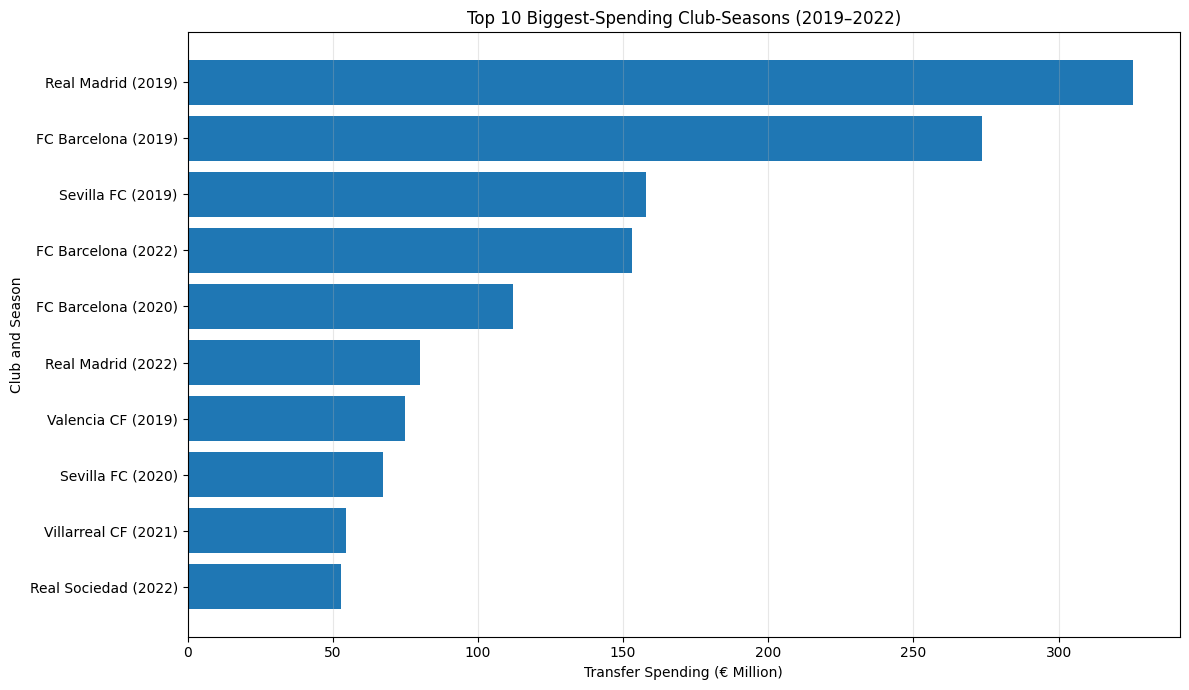


Interpretation:
Transfer spending was heavily concentrated among a small number of club-seasons. Real Madrid and FC Barcelona recorded the highest individual spending levels, while the remaining clubs operated with considerably smaller transfer budgets. This highlights the substantial financial difference between the largest clubs and the rest of the league.


GRAPH 4: HIGH SPENDING VS LOW SPENDING CLUBS


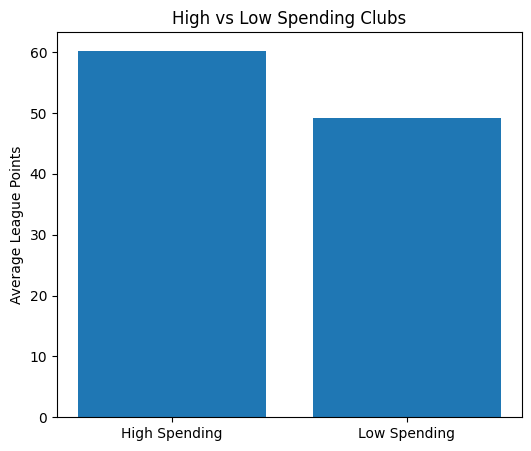


Interpretation:
High-spending clubs averaged significantly more league points than low-spending clubs. This suggests that financial investment provides a competitive advantage, but success still depends on how effectively those investments are utilized.


In [11]:
# transfer spending vs league points
print("\n\nGRAPH 1: TOTAL TRANSFER SPENDING VS LEAGUE POINTS")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    analysis_data['total_spending'],
    analysis_data['points'],
    s=80,
    alpha=0.7
)

plt.xlabel("Transfer Spending (€ Million)")
plt.ylabel("League Points")
plt.title("Transfer Spending vs League Points")

plt.grid(alpha=0.3)

plt.savefig("spending_vs_points.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("The scatter plot shows a clear upward trend between transfer spending and league points. Clubs investing more in transfers generally achieved higher league points, although some clubs performed well despite lower spending, highlighting the importance of efficient recruitment.")

# correlation heatmap
print("\n\nGRAPH 2: CORRELATION HEATMAP")
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    analysis_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("The heatmap shows that total transfer spending has a moderate positive correlation (0.51) with league points, indicating that higher spending is generally associated with better league performance. However, spending alone is not sufficient, as factors like squad quality and tactical management also influence results.")



# top 10 biggest spenders
print("\n\nGRAPH 3: TOP 10 BIGGEST SPENDERS")

import matplotlib.pyplot as plt

# sorting individual club season observations by spending
top_10_spenders = (analysis_data.sort_values(by='total_spending', ascending=False).head(10).copy()
)

# label containing both- club and season
top_10_spenders['club_season'] = (
    top_10_spenders['club_name'].astype(str)
    + " ("
    + top_10_spenders['season'].astype(str)
    + ")"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_spenders['club_season'][::-1],
    top_10_spenders['total_spending'][::-1]
)

plt.xlabel("Transfer Spending (€ Million)")
plt.ylabel("Club and Season")
plt.title("Top 10 Biggest-Spending Club-Seasons (2019–2022)")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig("top_10_biggest_spenders.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

# interpretation
print("\nInterpretation:")
print(
    "Transfer spending was heavily concentrated among a small number of "
    "club-seasons. Real Madrid and FC Barcelona recorded the highest "
    "individual spending levels, while the remaining clubs operated with "
    "considerably smaller transfer budgets. This highlights the substantial "
    "financial difference between the largest clubs and the rest of the league."
)


# average points comparison between high and low spending clubs
print("\n\nGRAPH 4: HIGH SPENDING VS LOW SPENDING CLUBS")
comparison = analysis_data.copy()

median_spending = comparison["total_spending"].median()

comparison["Group"] = comparison["total_spending"].apply(
    lambda x: "High Spending" if x >= median_spending else "Low Spending"
)

avg_points = comparison.groupby("Group")["points"].mean()

plt.figure(figsize=(6,5))

plt.bar(
    avg_points.index,
    avg_points.values
)

plt.ylabel("Average League Points")

plt.title("High vs Low Spending Clubs")

plt.savefig("high_vs_low_spending.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("High-spending clubs averaged significantly more league points than low-spending clubs. This suggests that financial investment provides a competitive advantage, but success still depends on how effectively those investments are utilized.")


#  Sporting Director Performance Matrix



SPORTING DIRECTOR PERFORMANCE MATRIX:


,club_seasons,average_spending,average_points,average_wins,average_goal_difference
sporting_director_category,,,,,
BIG SPENDER - SUCCESSFUL,18,86.544444,68.833333,19.722222,23.444444
SMART SPENDER,9,4.666889,59.444444,16.000000,13.000000
LOW INVESTMENT - LOW PERFORMANCE,18,5.653333,44.055556,10.833333,-10.833333
EXPENSIVE UNDERPERFORMER,9,19.188889,43.111111,10.444444,-8.222222




TRANSFER STRATEGY EFFICIENCY ANALYSIS:

Median Transfer Spending:
€13.03 million

Median Sporting Performance Score:
-0.261


TOP 10 MOST EFFICIENT CLUB SEASONS:
         club_name  season  total_spending  points  wins  goal_difference  points_per_million       sporting_director_category
Real Valladolid CF    2019            1.00      41    10              -19           41.000000 LOW INVESTMENT - LOW PERFORMANCE
        Levante UD    2021            1.25      41     9              -11           32.800000 LOW INVESTMENT - LOW PERFORMANCE
     Real Sociedad    2021            2.50      62    17               21           24.800000                    SMART SPENDER
        CA Osasuna    2022            2.00      47    12              -14           23.500000 LOW INVESTMENT - LOW PERFORMANCE
          SD Eibar    2020            2.00      42    11              -17           21.000000 LOW INVESTMENT - LOW PERFORMANCE
     Celta de Vigo    2020            2.50      37     7              -12 

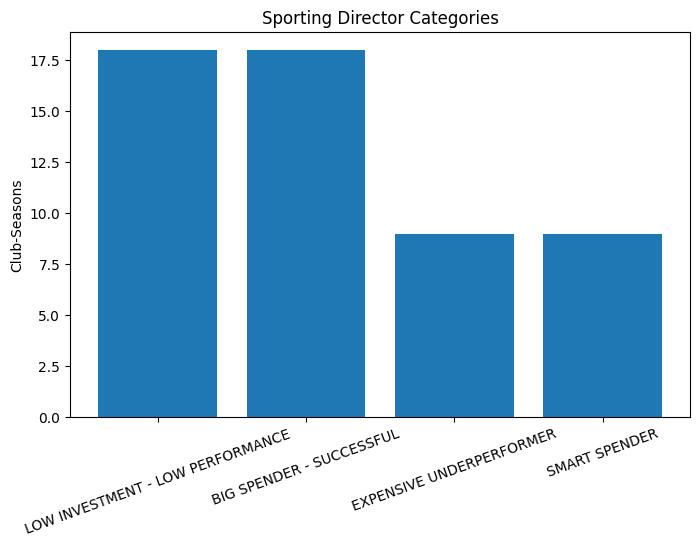


Interpretation:
The matrix categorizes clubs based on spending and performance outcomes. It identifies successful big spenders, smart spenders who achieved strong results with limited investment, expensive underperformers, and low-investment clubs with weaker performances, demonstrating that efficient spending is often more valuable than simply spending more.

Files saved:
1. top_10_transfer_efficiency.csv
2. top_10_biggest_spenders.csv
3. smart_spenders.csv
4. expensive_underperformers.csv
5. sporting_director_matrix_summary.csv
6. transfer_strategy_effectiveness.csv


In [12]:
import pandas as pd
import numpy as np

# Load the final dataset which is the source for analysis_data
final_data = pd.read_csv("final_football_transfer_performance_dataset.csv")

# Recreate analysis_data from final_data as it's used in this cell
analysis_data = final_data[
    [
        "club_name",
        "season",
        "total_transfers",
        "avg_age",
        "total_spending",
        "number_of_paid_transfers",
        "Free Transfer",
        "Internal Promotion",
        "Loan",
        "Loan Return",
        "Permanent Transfer",
        "Unknown",
        "points",
        "wins",
        "draws",
        "losses",
        "goals_scored",
        "goals_conceded",
        "goal_difference"
    ]
].copy()

# transfer startegy efficiency and sporting director analysis

# 1) copy dataset

df = analysis_data.copy()

# 2) creating transfer efficiency metrics

# avoiding division by zero
df['spending_for_efficiency'] = df['total_spending'].replace(0, np.nan)

# league points earned per €1 million spent
df['points_per_million'] = (
    df['points'] / df['spending_for_efficiency']
)

# wins per €1 million spent
df['wins_per_million'] = (
    df['wins'] / df['spending_for_efficiency']
)

# goal difference per €1 million spent
df['goal_difference_per_million'] = (
    df['goal_difference'] / df['spending_for_efficiency']
)

# 3) combined sporting performance score

# standardizing key performance indicators
df['points_z'] = (
    (df['points'] - df['points'].mean()) /
    df['points'].std()
)

df['goal_difference_z'] = (
    (df['goal_difference'] - df['goal_difference'].mean()) /
    df['goal_difference'].std()
)

df['wins_z'] = (
    (df['wins'] - df['wins'].mean()) /
    df['wins'].std()
)

# combined sporting performance score
df['sporting_performance_score'] = (
    0.5 * df['points_z'] +
    0.3 * df['goal_difference_z'] +
    0.2 * df['wins_z']
)

# 4) defining high/low spending and performance

spending_median = df['total_spending'].median()
performance_median = df['sporting_performance_score'].median()

df['spending_category'] = np.where(
    df['total_spending'] >= spending_median,
    'High Spending',
    'Low Spending'
)

df['performance_category'] = np.where(
    df['sporting_performance_score'] >= performance_median,
    'High Performance',
    'Low Performance'
)

# 5) sports director matrix

def classify_strategy(row):

    if row['spending_category'] == 'Low Spending' and \
       row['performance_category'] == 'High Performance':
        return 'SMART SPENDER'

    elif row['spending_category'] == 'High Spending' and \
         row['performance_category'] == 'High Performance':
        return 'BIG SPENDER - SUCCESSFUL'

    elif row['spending_category'] == 'High Spending' and \
         row['performance_category'] == 'Low Performance':
        return 'EXPENSIVE UNDERPERFORMER'

    else:
        return 'LOW INVESTMENT - LOW PERFORMANCE'


df['sporting_director_category'] = df.apply(
    classify_strategy,
    axis=1
)

# 6) top 10 "most efficient" club seasons

# including the only clubs that spent more than zero
efficiency_df = df[
    df['total_spending'] > 0
].copy()

top_efficiency = efficiency_df.sort_values(
    'points_per_million',
    ascending=False
)[[
    'club_name',
    'season',
    'total_spending',
    'points',
    'wins',
    'goal_difference',
    'points_per_million',
    'sporting_director_category'
]].head(10)

# 7) top 10 biggest spenders

top_spenders = df.sort_values(
    'total_spending',
    ascending=False
)[[
    'club_name',
    'season',
    'total_spending',
    'points',
    'wins',
    'goal_difference',
    'sporting_director_category'
]].head(10)

# 8) top 10 smartest spenders

smart_spenders = df[
    df['sporting_director_category'] == 'SMART SPENDER'
].sort_values(
    'sporting_performance_score',
    ascending=False
)[[
    'club_name',
    'season',
    'total_spending',
    'points',
    'wins',
    'goal_difference',
    'points_per_million',
    'sporting_performance_score'
]].head(10)

# 9) expensive underperformers

underperformers = df[
    df['sporting_director_category'] == 'EXPENSIVE UNDERPERFORMER'
].sort_values(
    'total_spending',
    ascending=False
)[[
    'club_name',
    'season',
    'total_spending',
    'points',
    'wins',
    'goal_difference',
    'sporting_performance_score'
]].head(10)

# 10) sporting director matrix summary

matrix_summary = df.groupby(
    'sporting_director_category'
).agg(
    club_seasons=('club_name', 'count'),
    average_spending=('total_spending', 'mean'),
    average_points=('points', 'mean'),
    average_wins=('wins', 'mean'),
    average_goal_difference=('goal_difference', 'mean')
).sort_values(
    'average_points',
    ascending=False
)

print("\n")
print("SPORTING DIRECTOR PERFORMANCE MATRIX:")

display(matrix_summary)

# 11) transfer strategy effectiveness

# using the transfer strategy columns available in analysis_df
strategy_columns = [
    'Free Transfer',
    'Internal Promotion',
    'Loan',
    'Loan Return',
    'Permanent Transfer',
    'Unknown'
]

# checking which strategy columns exist
available_strategies = [
    col for col in strategy_columns
    if col in df.columns
]

strategy_results = []

for strategy in available_strategies:

    # percentage of transfers represented by this strategy
    total_strategy_transfers = df[strategy].sum()

    total_all_transfers = df['total_transfers'].sum()

    strategy_share = (
        total_strategy_transfers /
        total_all_transfers * 100
    )

    # correlation with league points
    correlation = df[strategy].corr(
        df['points']
    )

    strategy_results.append({
        'transfer_strategy': strategy,
        'total_transfers': total_strategy_transfers,
        'share_of_all_transfers_percent': strategy_share,
        'correlation_with_points': correlation
    })

strategy_results = pd.DataFrame(
    strategy_results
).sort_values(
    'correlation_with_points',
    ascending=False
)

# final result

print("\n")
print("TRANSFER STRATEGY EFFICIENCY ANALYSIS:")

print("\nMedian Transfer Spending:")
print(f"€{spending_median:.2f} million")

print("\nMedian Sporting Performance Score:")
print(f"{performance_median:.3f}")

print("\n")
print("TOP 10 MOST EFFICIENT CLUB SEASONS:")


print(
    top_efficiency.to_string(index=False)
)

print("\n")
print("TOP 10 BIGGEST SPENDERS:")

print(
    top_spenders.to_string(index=False)
)

print("\n")
print("TOP SMART SPENDERS:")

print(
    smart_spenders.to_string(index=False)
)

print("\n")
print("EXPENSIVE UNDERPERFORMERS:")

print(
    underperformers.to_string(index=False)
)

print("\n")
print("SPORTING DIRECTOR MATRIX:")

print(
    matrix_summary.to_string()
)


print("\n")
print("TRANSFER STRATEGY EFFECTIVENESS:")


print(
    strategy_results.to_string(index=False)
)


# saving results to csv files

top_efficiency.to_csv(
    'top_10_transfer_efficiency.csv',
    index=False
)

top_spenders.to_csv(
    'top_10_biggest_spenders.csv',
    index=False
)

smart_spenders.to_csv(
    'smart_spenders.csv',
    index=False
)

underperformers.to_csv(
    'expensive_underperformers.csv',
    index=False
)

matrix_summary.to_csv(
    'sporting_director_matrix_summary.csv'
)

strategy_results.to_csv(
    'transfer_strategy_effectiveness.csv',
    index=False
)

# graph
print("\n\nGRAPH: SPORTING DIRECTOR DECISION MATRIX")
category_counts = df["sporting_director_category"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xticks(rotation=20)

plt.ylabel("Club-Seasons")

plt.title("Sporting Director Categories")

plt.savefig("sporting_director.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nInterpretation:")
print("The matrix categorizes clubs based on spending and performance outcomes. It identifies successful big spenders, smart spenders who achieved strong results with limited investment, expensive underperformers, and low-investment clubs with weaker performances, demonstrating that efficient spending is often more valuable than simply spending more.")




print("\nFiles saved:")
print("1. top_10_transfer_efficiency.csv")
print("2. top_10_biggest_spenders.csv")
print("3. smart_spenders.csv")
print("4. expensive_underperformers.csv")
print("5. sporting_director_matrix_summary.csv")
print("6. transfer_strategy_effectiveness.csv")

# Business Recommendations

Based on my analysis in this project, the following recommendations can help Spanish football clubs (LaLiga in this case) make more informed transfer decisions:

1. Focus on **efficient spending** rather than maximum spending.

Although transfer spending showed a moderate positive relationship with league points, simply spending large amounts of money does not guarantee success. Clubs should prioritize signing players who fit their tactical system instead of pursuing expensive signings solely based on reputation.

2. Build long-term recruitment strategies.

The analysis shows that clubs classified as *smart spenders* achieved competitive results despite relatively low transfer expenditure. This highlights the importance of strong scouting networks, youth development, and strategic recruitment rather than relying entirely on financial resources.

3. Utilize loan return players effectively.

Among all transfer strategies, loan returns demonstrated the strongest positive association with league performance. Clubs should therefore monitor and develop players during loan spells and integrate successful returning players into the first team squad whenever possible, which can turn out to be a favourable outcome for a win.

4. Regularly evaluate transfer return on investment (**ROI**).

Several clubs invested considerable transfer fees but failed to translate those investments into improved league performance. Clubs should continuously evaluate whether transfer spending is generating measurable sporting benefits and adjust recruitment policies accordingly.

5. Combine Financial and Sporting Data in decision-making.

Transfer decisions should not rely solely on scouting opinions. Modern football clubs should integrate **statistical analysis**, **financial planning**, **player performance metrics**, and **squad requirements** before making transfer investments.

# Final Conclusion

This project analyzed the relationship between transfer market activity and club performance in LaLiga over four seasons (2019–2022). By integrating player transfer records with club performance statistics, my study explored how transfer spending and recruitment strategies influence sporting success.

The findings indicate that clubs investing more in the transfer market generally achieved better league performance, with a moderate positive correlation of 0.506 between transfer spending and league points, which is quite higher than expected. Regression analysis further showed that transfer expenditure has a statistically significant positive impact on league points, although it explains only a part of overall team performance.

The analysis also demonstrated that financial investment alone is not sufficient for success. Several clubs achieved strong results despite relatively low spending, while others underperformed despite significant investment. This highlights the importance of recruitment efficiency, squad planning, and effective sporting management.

Furthermore, different transfer strategies produced different outcomes. Loan return players displayed the strongest positive relationship with league performance, whereas heavy reliance on loans and free transfers was generally associated with weaker results.

Overall, the project concludes that successful football clubs are not necessarily the clubs that spend the most money, but the clubs that spend their money **most effectively**. **Strategic recruitment**, **efficient resource allocation**, and **data driven decision-making** together play a more important role in achieving long term sporting success than transfer expenditure alone.



I would like to conclude this project on a final note:

"In modern football, success is'nt determined by how much a club spends on its players, but rather on **intelligent investment** taking into account, data driven recruitment and efficient transfer strategies."